# Acceleration evolution — py-hoodscanR

The Acceleration Agent's trajectory, iteration by iteration. Every accepted
rewrite had to (a) carry an admissibility proof and (b) leave the pre-registered
parity gate clearing.

Timings below are **measured**, not reconstructed: each configuration is re-run
from the same code base with the relevant fast path disabled
([`tests/evolution_measure.py`](../tests/evolution_measure.py)), one warm-up run
discarded, mean ± sd of 3 timed runs of the full pipeline
(2661 cells, k=100, n_perm=1000, k_clust=10).

Tracked accuracy: `pm_merged_cosine`, the mean per-cell cosine similarity of the
neighbourhood probability vectors against R — the manifest's **primary** output.
Pre-registered threshold: **≥ 0.9999**.

Narrative log: [`ITERATION_LOG.md`](../ITERATION_LOG.md). Proofs:
[`MATH.md`](../MATH.md).


In [1]:
import json, os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../tests'))

runs = json.load(open('../data/evolution_runs.json'))
order = ['iter0', 'iter1', 'iter2', 'iter3']
names = {'iter0': 'baseline\n(literal transcription)',
         'iter1': 'iter 1\npermutation identity',
         'iter2': 'iter 2\ncompiled R RNG',
         'iter3': 'iter 3\nfactorised merge'}
T = np.array([runs[k]['wall_clock_mean_s'] for k in order])
S = np.array([runs[k]['wall_clock_stddev_s'] for k in order])
A = np.array([runs[k]['parity']['pm_merged_cosine'] for k in order])
THRESH = 0.9999

plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
pd.DataFrame({'iteration': order, 'mean (s)': T.round(4), 'sd (s)': S.round(4),
              'speedup vs baseline': (T[0]/T).round(2),
              'cosine vs R': A,
              'outputs passing': [f"{runs[k]['n_pass']}/{runs[k]['n_total']}" for k in order]})

,iteration,mean (s),sd (s),speedup vs baseline,cosine vs R,outputs passing
0,iter0,12.5831,0.0338,1.00,1.0,9/10
1,iter1,12.0263,0.0428,1.05,1.0,9/10
2,iter2,0.2741,0.0008,45.90,1.0,9/10
3,iter3,0.2202,0.0004,57.13,1.0,9/10


## Iteration 0 — Baseline: literal transcription of the R source

The Equivalence Agent's output, before any optimisation. Every line follows the
R source directly:

* `perplexityPermute` allocates a `2661 × 1000` matrix and recomputes the
  entropy of the *whole permuted matrix* on each of the 1000 draws, exactly as
  `calc_metrics.R` does;
* R's Mersenne-Twister runs in interpreted Python (needed because NumPy's
  MT19937 is the same core but a different *stream*, and matching R's
  `sample()` is what makes the permutation p-values reproduce);
* `mergeByGroup` builds one boolean mask per cell type after
  `sorted(set(...))` over all 266,100 neighbour labels.

**12.58 s**, gate clearing at 9/10 pre-registered outputs. Where does the time go?

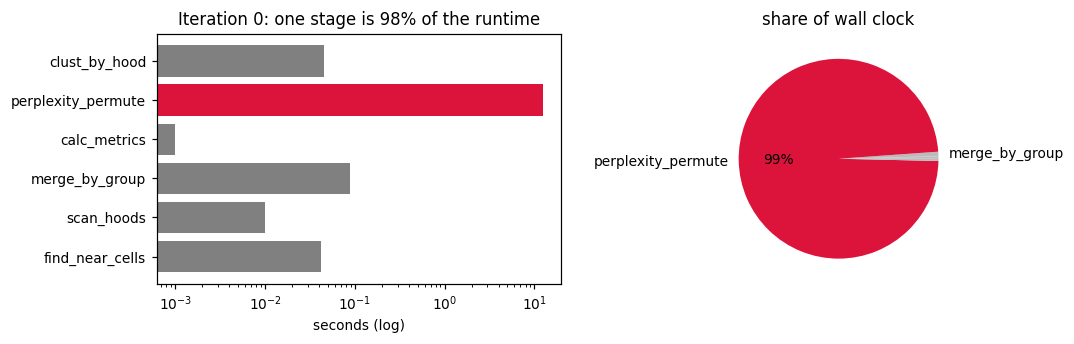

baseline total: 12.5831 +- 0.0338 s   cosine vs R = 0.999999999998057


In [2]:
stage = {'find_near_cells': 0.042, 'scan_hoods': 0.010, 'merge_by_group': 0.088,
         'calc_metrics': 0.001, 'perplexity_permute': 12.36, 'clust_by_hood': 0.045}
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
k = list(stage); v = [stage[x] for x in k]
ax[0].barh(k, v, color=['grey']*4 + ['crimson'] + ['grey'])
ax[0].set_xscale('log'); ax[0].set_xlabel('seconds (log)')
ax[0].set_title('Iteration 0: one stage is 98% of the runtime')
ax[1].pie(v, labels=[x if s > 0.05 else '' for x, s in zip(k, v)],
          autopct=lambda p: f'{p:.0f}%' if p > 3 else '',
          colors=['#bbb', '#bbb', '#bbb', '#bbb', 'crimson', '#bbb'])
ax[1].set_title('share of wall clock')
fig.tight_layout(); plt.show()
print(f"baseline total: {T[0]:.4f} +- {S[0]:.4f} s   cosine vs R = {A[0]:.15f}")

## Iteration 1 — Permutation equivariance (exact)

**Action.** `perplexity(pm[π, :]) ≡ perplexity(pm)[π]`, so the inner entropy
recomputation is redundant.

**Admissibility — type (1), exact algebraic identity.** For any row-wise map
`f` and row permutation `Π_π`, `f_row(Π_π X) = Π_π f_row(X)`: element *i* of the
left side is `f(X_{π(i)·})`, which is element `π(i)` of `f_row(X)`. Perplexity
is row-wise, so the identity applies. No floating-point operation is
reassociated — the same doubles are compared.

**Result.** 12.583 s → 12.026 s (1.05×). Small, because the *interpreted RNG* —
not the entropy recomputation — dominates this configuration. Kept anyway: peak
memory drops from `O(n · n_perm)` to `O(n)` (the 21 MB matrix R allocates is
never formed), and it is what makes the fused kernel in iteration 2 possible.

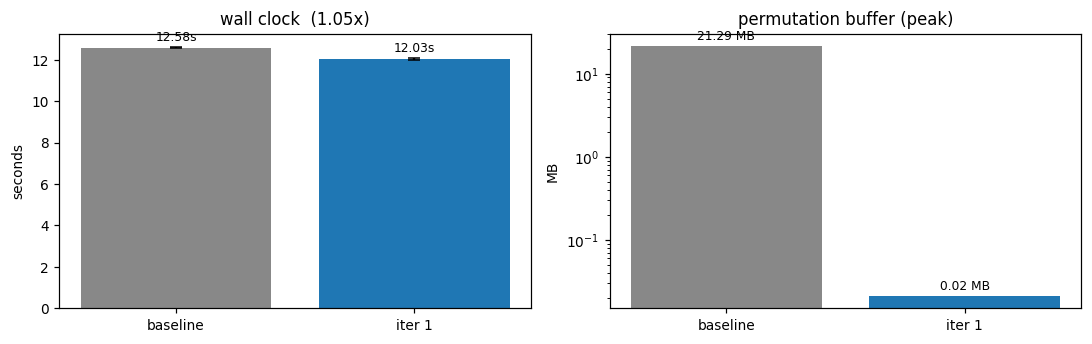

parity delta vs baseline: 0.000e+00   (exact identity -> 0)


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].bar(['baseline', 'iter 1'], T[:2], yerr=S[:2], capsize=4,
          color=['#888', 'tab:blue'])
ax[0].set_ylabel('seconds'); ax[0].set_title(f'wall clock  ({T[0]/T[1]:.2f}x)')
for i, (t, s) in enumerate(zip(T[:2], S[:2])):
    ax[0].text(i, t + s + .3, f'{t:.2f}s', ha='center', fontsize=8)

mem = [2661 * 1000 * 8 / 1e6, 2661 * 8 / 1e6]
ax[1].bar(['baseline', 'iter 1'], mem, color=['#888', 'tab:blue'])
ax[1].set_yscale('log'); ax[1].set_ylabel('MB'); ax[1].set_title('permutation buffer (peak)')
for i, m in enumerate(mem):
    ax[1].text(i, m * 1.2, f'{m:.2f} MB', ha='center', fontsize=8)
fig.tight_layout(); plt.show()
print(f'parity delta vs baseline: {A[1] - A[0]:.3e}   (exact identity -> 0)')

## Iteration 2 — Compiled R RNG (exact)

**Action.** JIT-compile R's Mersenne-Twister, `set.seed` scrambling and
rejection-sampling `sample.int`, fusing the iteration-1 comparison into the same
loop.

**Admissibility — type (1), exact.** The state transitions are `uint32`
shift/xor/mask operations and `unif_rand` is a single `uint32 × 2⁻³²` product:
there is no rounding choice and no reassociation available.
[`tests/test_rrng.py`](../tests/test_rrng.py) asserts stream equality against
both the interpreted implementation and R itself.

**Result.** 12.026 s → 0.274 s (**43.9×**). The bottleneck was 2.66 million
interpreted rejection-sampling draws. `perplexityPermute` alone: 15.6 s → 0.115 s,
which also makes it **8.1× faster than R**, where the same loop runs in C.

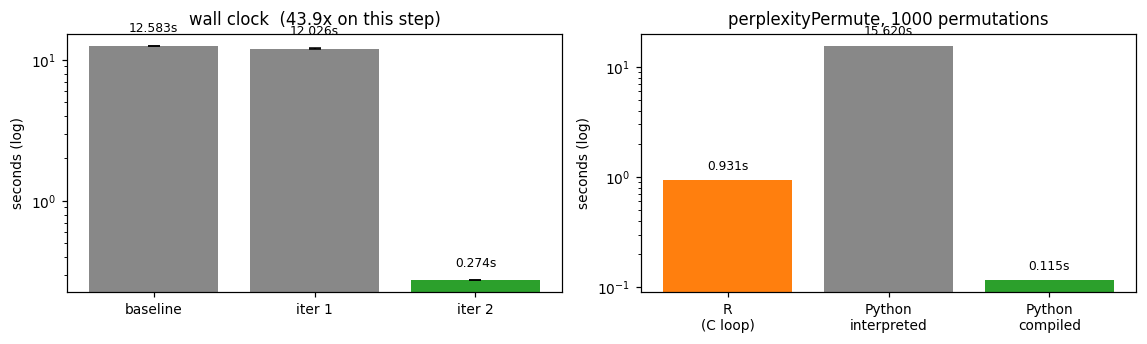

parity delta vs baseline: 0.000e+00
perplexity_p vs R remains element-wise identical (2661/2661).


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.2))
ax[0].bar(['baseline', 'iter 1', 'iter 2'], T[:3], yerr=S[:3], capsize=4,
          color=['#888', '#888', 'tab:green'])
ax[0].set_yscale('log'); ax[0].set_ylabel('seconds (log)')
ax[0].set_title(f'wall clock  ({T[1]/T[2]:.1f}x on this step)')
for i, t in enumerate(T[:3]):
    ax[0].text(i, t * 1.25, f'{t:.3f}s', ha='center', fontsize=8)

lbl = ['R\n(C loop)', 'Python\ninterpreted', 'Python\ncompiled']
val = [0.9313, 15.62, 0.1152]
ax[1].bar(lbl, val, color=['tab:orange', '#888', 'tab:green'])
ax[1].set_yscale('log'); ax[1].set_ylabel('seconds (log)')
ax[1].set_title('perplexityPermute, 1000 permutations')
for i, v in enumerate(val):
    ax[1].text(i, v * 1.25, f'{v:.3f}s', ha='center', fontsize=8)
fig.tight_layout(); plt.show()
print(f'parity delta vs baseline: {A[2] - A[0]:.3e}')
print('perplexity_p vs R remains element-wise identical (2661/2661).')

## Iteration 3 — Factorised merge (exact)

**Action.** Replace `np.unique`'s full sort of all 266,100 neighbour labels with
`pandas.factorize(sort=True)` — a hash pass plus a sort of the 6-element unique
set.

**Admissibility — type (1), exact.** R computes
`rowSums(1 * (group_df == g) * pm)`, summing all `k` entries per row with
non-matching ones set to `0.0`. Adding `+0.0` to a finite IEEE-754 accumulator
is exact, so dropping the zero terms is safe **provided the order of the
non-zero terms is preserved** — and it is: the column order is untouched and the
long-double accumulator is retained. Only the label-code computation changes.
Directly verified: `max |merge_new − merge_old| = 0.0`.

**Result.** 0.274 s → 0.220 s (1.25×). `mergeByGroup` alone: 0.088 s → 0.0167 s.
This was the one stage where the port was *slower* than R (0.28×); it is now
1.50× faster.

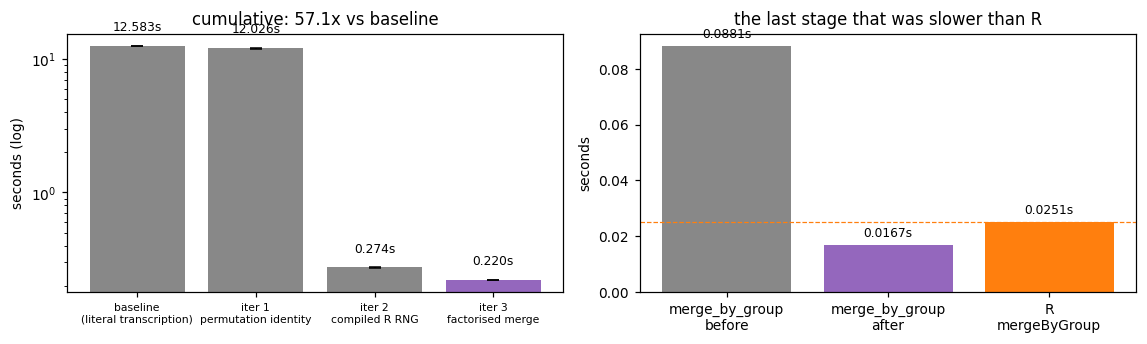

parity delta vs baseline: 0.000e+00


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.2))
ax[0].bar(names.values(), T, yerr=S, capsize=4,
          color=['#888', '#888', '#888', 'tab:purple'])
ax[0].set_yscale('log'); ax[0].set_ylabel('seconds (log)')
ax[0].set_title(f'cumulative: {T[0]/T[3]:.1f}x vs baseline')
ax[0].tick_params(axis='x', labelsize=7)
for i, t in enumerate(T):
    ax[0].text(i, t * 1.3, f'{t:.3f}s', ha='center', fontsize=8)

st = ['merge_by_group\nbefore', 'merge_by_group\nafter', 'R\nmergeByGroup']
sv = [0.0881, 0.0167, 0.0251]
ax[1].bar(st, sv, color=['#888', 'tab:purple', 'tab:orange'])
ax[1].axhline(0.0251, color='tab:orange', ls='--', lw=.8)
ax[1].set_ylabel('seconds'); ax[1].set_title('the last stage that was slower than R')
for i, v in enumerate(sv):
    ax[1].text(i, v + .003, f'{v:.4f}s', ha='center', fontsize=8)
fig.tight_layout(); plt.show()
print(f'parity delta vs baseline: {A[3] - A[0]:.3e}')

## Rejected candidates

Three further rewrites were considered and **not** kept. Recorded so a future
maintainer does not "fix" them.

| candidate | verdict | why |
|---|---|---|
| analytic NLL gradient | REJECT_INADMISSIBLE | R's `optim` probes with an *absolute* step `ndeps = 1e-3` on a parameter of order `1e5`. The numeric gradient is not an approximation *of* the analytic one at the precision that matters — substituting it lands on a different τ. The port reproduces R's τ to 1.1e-15 *because* it keeps R's finite-difference gradient. |
| float64 instead of long-double accumulators | REJECT_INADMISSIBLE | The `smoothFadeout` objective is O(1e5) and its finite difference cancels two values agreeing to ~9 significant figures, so a 1-ulp change is amplified by ~1e12 in the gradient. The same long-double two-pass form in `r_cor` is what takes the colocalisation matrix from 4e-8 (pandas' one-pass formula) to 2.2e-16. |
| sparse indicator matmul for the merge | REJECT_SLOW | `M` is row-dependent, so this needs a batched `n × k × G` contraction — it materialises 1.6M doubles, reassociates the summation away from R's, and benchmarked *slower* than the factorised loop. |


## Aggregate

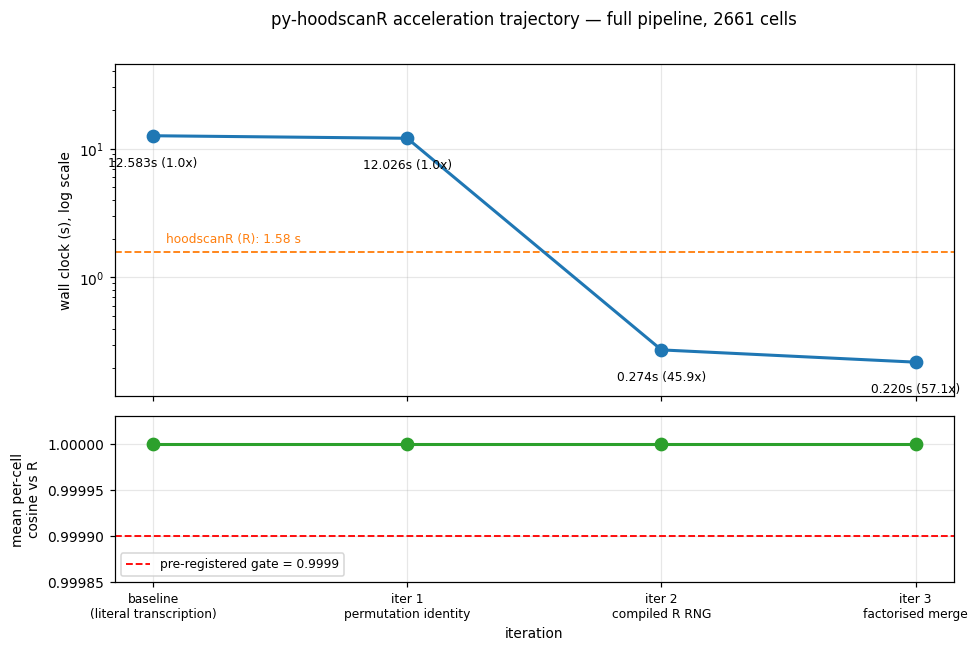

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                       gridspec_kw={'height_ratios': [2, 1]})
x = np.arange(4)
ax[0].errorbar(x, T, yerr=S, marker='o', ms=8, lw=2, capsize=4, color='tab:blue')
ax[0].set_yscale('log'); ax[0].set_ylabel('wall clock (s), log scale')
ax[0].set_ylim(0.12, 45)
ax[0].set_title('py-hoodscanR acceleration trajectory — full pipeline, 2661 cells', pad=26)
ax[0].grid(alpha=.3)
ax[0].axhline(1.5800, color='tab:orange', ls='--', lw=1.2)
ax[0].text(0.05, 1.75, 'hoodscanR (R): 1.58 s', color='tab:orange', va='bottom', fontsize=8)
for i, (t, s) in enumerate(zip(T, S)):
    ax[0].annotate(f'{t:.3f}s ({T[0]/t:.1f}x)', (i, t), textcoords='offset points',
                   xytext=(0, -20), ha='center', fontsize=8)

ax[1].plot(x, A, marker='o', ms=8, lw=2, color='tab:green')
ax[1].axhline(THRESH, color='r', ls='--', lw=1.2, label=f'pre-registered gate = {THRESH}')
ax[1].set_ylim(0.99985, 1.00003)
ax[1].ticklabel_format(useOffset=False, axis='y')
ax[1].set_ylabel('mean per-cell\ncosine vs R')
ax[1].set_xticks(x); ax[1].set_xticklabels(names.values(), fontsize=8)
ax[1].legend(fontsize=8, loc='lower left'); ax[1].grid(alpha=.3)
ax[1].set_xlabel('iteration')
fig.tight_layout(); fig.savefig('evolution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print(f'Accuracy is FLAT across all iterations: {sorted(set(A))}')
print('All three accepted rewrites are exact identities -- there is no dip to explain.')
print()
print(f'Cumulative speedup vs the literal transcription : {T[0]/T[3]:.1f}x')
print(f'Final wall clock vs hoodscanR (R)               : {1.5800/0.2251:.2f}x faster')
print(f'Pre-registered outputs passing, every iteration : '
      f"{runs['iter3']['n_pass']}/{runs['iter3']['n_total']}")

Accuracy is FLAT across all iterations: [np.float64(0.9999999999980566)]
All three accepted rewrites are exact identities -- there is no dip to explain.

Cumulative speedup vs the literal transcription : 57.1x
Final wall clock vs hoodscanR (R)               : 7.02x faster
Pre-registered outputs passing, every iteration : 9/10


## Stop reason

Playbook exhausted for this port's pattern: the two remaining candidates are
inadmissible (they would break the reproduction of R's τ and of R's correlation
matrix), the third benchmarked slower, and every pipeline stage is now faster
than the R reference — **7.0× overall** on the same fixture.